# Wide-close degeneracy



In [1]:
from os import path
import copy
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import collections
from astropy import units as u
from pyLIMA import event
from pyLIMA import telescopes
from pyLIMA.models import PSPL_model, USBL_model
from pyLIMA.outputs import pyLIMA_plots
from pyLIMA.parallax import JPL_ephemerides
from pyLIMA import toolbox
from pyLIMA.fits import DE_fit
from pyLIMA.fits import TRF_fit
from pyLIMA.simulations import simulator
from matplotlib.ticker import MaxNLocator

Simulate two binary models, one with small separation and one with a large distance between the binary components. 

## Wide binary model

In [2]:
sim_event1 = event.Event(ra=265.0, dec=-17.5)
sim_event1.name = 'Sim_event_1'

In [3]:
tel1 = simulator.simulate_a_telescope(name='tel1', time_start=2459500.0,
                                        time_end=2459750.0, sampling=4,
                                        location='Earth', camera_filter='I',
                                        uniform_sampling=True, astrometry=False)
sim_event1.telescopes.append(tel1)
sim_event1.check_event()

check_event  : Everything looks fine...


In [4]:
# Define parameters 
# t0, u0, tE, rho, s, q, alpha, fsource, ftotal
# Wide binary model
usbl1 = USBL_model.USBLmodel(sim_event1, parallax=['None', 0.0], blend_flux_parameter='ftotal')
usbl1_parameters = [2459651.8548187, -2.09, 20.0, 0.00001, 5.0, 1.0, 45.0, 2500.243993694058444, 2500.243993694058444]
pyLIMA_parameters_wide = usbl1.compute_pyLIMA_parameters(usbl1_parameters)

In [5]:
simulator.simulate_lightcurve(usbl1, pyLIMA_parameters_wide)

In [6]:
def generate_model_lightcurve(event_model, pyLIMA_parameters):
    """Calculate the model lightcurve using a simulated telescope object"""
    
    model_telescope = pyLIMA_plots.create_telescopes_to_plot_model(event_model, pyLIMA_parameters)[0]
    
    flux_model = event_model.compute_the_microlensing_model(model_telescope, pyLIMA_parameters)['photometry']
    
    magnitude = toolbox.brightness_transformation.flux_to_magnitude(flux_model)
    
    model_telescope.lightcurve["mag"] = magnitude * u.mag
    
    mask = ~np.isnan(magnitude)
    model_telescope.lightcurve = model_telescope.lightcurve[mask]

    return model_telescope

In [7]:
def plot_lc(model, pyLIMA_parameters, plot_file, xmin=None, xmax=None):
    """
    Function to plot simulated Roman lightcurves, showing the full extent of the multi-season lightcurve plus 
    an inset box showing a zoom in lightcurve around the event peak. 

    Parameters:
        model  Object  Model object
        pyLIMA_parameters dict  PyLIMA-format parameter set
        plot_file  str    File path for saved PNG plot
        xmin float [optional] Minimum timestamp for x axis 
        xmax float [optional] Maximum timestamp for x axis 
        
    Returns:
        None, output lightcurve saved to plot_file
    """
    PLOT_COLORS = {
    'W149': '#03A66A',
    'Z087': '#2E03A6'
    }
    
    fig, axs = plt.subplots(1, 1, figsize=(10,10))
    
    dt = 2450000.0

    for index,tel in enumerate(model.event.telescopes):
        if tel.lightcurve is not None:
            axs.errorbar(
                tel.lightcurve['time'].value-dt, tel.lightcurve['mag'], yerr=tel.lightcurve['err_mag'], 
                ms=120, ls='none', c=PLOT_COLORS['W149'], label=tel.name
            )
    
    axs.invert_yaxis()
    
    axs.set_xlabel('JD-' + str(dt) + ' [days]', fontsize=20) 
    axs.set_ylabel('Mag', fontsize=20)
    axs.tick_params(axis='x', labelsize=18)
    axs.tick_params(axis='y', labelsize=18)
    
    axs.grid()
    #axs.legend(fontsize=18)
    
    axs.tick_params(axis='x', labelsize=18)
    axs.tick_params(axis='y', labelsize=18)

    if xmin:
        axs.set_xlim(xmin, xmax)
        
    model_telescope = generate_model_lightcurve(model, pyLIMA_parameters)
    axs.plot(model_telescope.lightcurve['time'].value-dt, model_telescope.lightcurve['mag'], c='black', ls='-', alpha=0.6)
        
    plt.tight_layout()
    
    plt.savefig(plot_file)

In [8]:
def plot_geometry(microlensing_model, model_parameters, plot_file, bokeh_plot=None, xmin=-1.0, xmax=1.0, ymin=-1.0, ymax=1.0, 
                  critical_curves=True, plot_legend=True):
    """Plot the lensing geometry (i.e source trajectory) and the table of best
    parameters.
    :param object fit: a fit object. See the microlfits for more details.
    :param list best_parameters: a list containing the model you want to plot the
    trajectory
    """
    MAX_PLOT_TICKS = 2
    MARKER_SYMBOLS = np.array(
    [['o', '.', '*', 'v', '^', '<', '>', 's', 'p', 'd', 'x'] * 10])

    MARKERS_COLORS = plt.rcParams["axes.prop_cycle"]

    pyLIMA_parameters = microlensing_model.compute_pyLIMA_parameters(model_parameters)

    faketelescopes = pyLIMA_plots.create_telescopes_to_plot_model(microlensing_model,
                                                     pyLIMA_parameters)

    fig_size = [10, 10]
    figure_trajectory = plt.figure(figsize=(fig_size[0], fig_size[1]), dpi=75)

    figure_axes = figure_trajectory.add_subplot(111, aspect=1)
    figure_axes.set_aspect('equal', adjustable='box')
    plt.subplots_adjust(top=0.8, bottom=0.1, left=0.2, right=0.9, wspace=0.1,
                        hspace=0.1)
    if bokeh_plot is not None:

        bokeh_geometry = figure(width=600, height=600, x_range=(-3, 3), y_range=(-3, 3),
                                x_axis_label=r'$$x [\theta_E]$$',
                                y_axis_label=r'$$y [\theta_E]$$')

    else:

        bokeh_geometry = None

    for telescope in faketelescopes:

        if telescope.lightcurve is not None:

            platform = 'Earth'

            if telescope.location == 'Space':

                platform = telescope.name
                linestyle = '--'

            else:

                linestyle = '-'

            #reference_telescope = telescope

            telescope_index = \
                [i for i in range(len(microlensing_model.event.telescopes)) if
                 microlensing_model.event.telescopes[i].name == telescope.name][0]


            (source1_trajectory_x, source1_trajectory_y,
             source2_trajectory_x, source2_trajectory_y,
             dseparation, dalpha) = microlensing_model.sources_trajectory(
                telescope, pyLIMA_parameters,
                data_type='photometry')

            ind_color = telescope_index % len(MARKERS_COLORS.by_key()["color"])
            color = MARKERS_COLORS.by_key()["color"][ind_color]
            figure_axes.plot(source1_trajectory_x, source1_trajectory_y,
                             c=color,
                             label=platform, linestyle=linestyle)

            if bokeh_geometry is not None:

                bokeh_geometry.line(source1_trajectory_x,
                                    source1_trajectory_y,
                                    color=color,
                                    legend_label=platform)

            if source2_trajectory_y is not None:

                figure_axes.plot(source2_trajectory_x, source2_trajectory_y,
                                 c=color, alpha=0.5,
                                 linestyle=linestyle)

                if bokeh_geometry is not None:

                    bokeh_geometry.line(source2_trajectory_x,
                                    source2_trajectory_y,
                                    color=color, alpha=0.5)



            for trajectory in [[source1_trajectory_x, source1_trajectory_y],
                         [source2_trajectory_x, source2_trajectory_y] ]:

                trajectory_x,trajectory_y=trajectory

                if trajectory_x is not None:

                    for ind in [-2, -1, 0, 1, 2]:

                        try:

                            index = np.argmin(
                                np.abs(telescope.lightcurve['time'].value -
                                       (pyLIMA_parameters['t0'] + ind * pyLIMA_parameters['tE'])))
                            sign = np.sign(trajectory_x[index + 1] - trajectory_x[index])
                            derivative = (trajectory_y[index - 1] - trajectory_y[index + 1]) / (
                                    trajectory_x[index - 1] - trajectory_x[index + 1])

                            figure_axes.annotate('',
                                                 xy=(trajectory_x[index], trajectory_y[index]),
                                                 xytext=(trajectory_x[index] - (
                                                         trajectory_x[index + 1] -
                                                         trajectory_x[index]) * 0.001,
                                                         trajectory_y[index] - (
                                                                 trajectory_x[index + 1] -
                                                                 trajectory_x[
                                                                     index]) * 0.001 *
                                                         derivative),
                                                 arrowprops=dict(arrowstyle="->",
                                                                 mutation_scale=35,
                                                                 color=color))

                            if bokeh_geometry is not None:
                                oh = OpenHead(line_color=color, line_width=1)

                                bokeh_geometry.add_layout(Arrow(end=oh,
                                                                x_start=trajectory_x[index],
                                                                y_start=trajectory_y[index],
                                                                x_end=trajectory_x[
                                                                          index] + sign * 0.001,
                                                                y_end=trajectory_y[
                                                                          index] + sign *
                                                                      0.001 * derivative))

                        except IndexError:

                            pass

    if microlensing_model.parallax_model[0] != 'None':

        telescope = faketelescopes[0]
        try:
            origin_t0par_index = np.argmin(
                np.abs(telescope.lightcurve['time'].value -
                       microlensing_model.parallax_model[1]))
            (source1_trajectory_x, source1_trajectory_y,
             source2_trajectory_x, source2_trajectory_y,
             dseparation, dalpha) = microlensing_model.sources_trajectory(
                telescope, pyLIMA_parameters,
                data_type='photometry')

        except AttributeError:
            origin_t0par_index = np.argmin(
                np.abs(telescope.astrometry['time'].value -
                       microlensing_model.parallax_model[1]))
            (source1_trajectory_x, source1_trajectory_y,
             source2_trajectory_x, source2_trajectory_y,
             dseparation, dalpha) = microlensing_model.sources_trajectory(
                telescope, pyLIMA_parameters,
                data_type='astrometry')
        # print(telescope.lightcurve['time'].value,
        #      microlensing_model.parallax_model[1],
        #      origin_t0par_index)

        # print(trajectory_x, trajectory_y)
        # import pdb;
        # pdb.set_trace()
        origin_t0par = np.array(
            (source1_trajectory_x[origin_t0par_index],
             source1_trajectory_y[origin_t0par_index]))
        # origin_t0par += 0.1

        piEN = pyLIMA_parameters['piEN']
        piEE = pyLIMA_parameters['piEE']

        EN_trajectory_angle = parallax.EN_trajectory_angle(piEN, piEE)

        plot_angle = -EN_trajectory_angle

        try:

            plot_angle += pyLIMA_parameters['alpha']

        except KeyError:

            pass

        north = [0.1, 0]
        east = [0, 0.1]

        North = [0.105, 0]
        East = [0, 0.105]

        rota_mat = np.array([[np.cos(plot_angle), -np.sin(plot_angle)],
                             [np.sin(plot_angle), np.cos(plot_angle)]])

        east = np.dot(rota_mat, east)
        north = np.dot(rota_mat, north)
        East = np.dot(rota_mat, East)
        North = np.dot(rota_mat, North)

        plt.annotate('',
                     xy=(origin_t0par[0] + east[0], origin_t0par[1] + east[1]),
                     xytext=(origin_t0par[0], origin_t0par[1]),
                     arrowprops=dict(arrowstyle="->", lw=3, alpha=0.5))
        plt.annotate('E', xy=(origin_t0par[0] + East[0], origin_t0par[1] + East[1]),
                     xytext=(origin_t0par[0] + East[0], origin_t0par[1] + East[1]),
                     weight='bold', alpha=0.5, ha='center', va='center',
                     rotation=np.rad2deg(plot_angle))

        plt.annotate('', xy=(
            origin_t0par[0] + north[0], origin_t0par[1] + north[1]),
                     xytext=(origin_t0par[0], origin_t0par[1]),
                     arrowprops=dict(arrowstyle="->", lw=3, alpha=0.5))
        plt.annotate('N',
                     xy=(origin_t0par[0] + North[0], origin_t0par[1] + North[1]),
                     xytext=(
                         origin_t0par[0] + North[0], origin_t0par[1] + North[1]),
                     weight='bold', alpha=0.5, ha='center', va='center',
                     rotation=np.rad2deg(plot_angle))

        if bokeh_geometry is not None:
            bokeh_geometry.add_layout(
                Arrow(end=OpenHead(line_color="grey", line_width=1),
                      x_start=origin_t0par[0], y_start=origin_t0par[1],
                      x_end=origin_t0par[0] + North[0],
                      y_end=origin_t0par[1] + North[1]))
            bokeh_geometry.add_layout(
                Arrow(end=OpenHead(line_color="grey", line_width=1),
                      x_start=origin_t0par[0], y_start=origin_t0par[1],
                      x_end=origin_t0par[0] + East[0],
                      y_end=origin_t0par[1] + East[1]))

    if 'BL' in microlensing_model.model_type():

        from pyLIMA.caustics import binary_caustics

        regime, caustics, cc = \
            binary_caustics.find_2_lenses_caustics_and_critical_curves(
                pyLIMA_parameters['separation'],
                pyLIMA_parameters['mass_ratio'],
                resolution=5000)

        center_of_mass = (pyLIMA_parameters['separation'] *
                          pyLIMA_parameters['mass_ratio'] / (
                1 + pyLIMA_parameters['mass_ratio']))
        plt.scatter(-center_of_mass, 0, s=10, c='k')
        plt.scatter(-center_of_mass + pyLIMA_parameters['separation'], 0, s=10, c='k')

        for count, caustic in enumerate(caustics):

            try:
                figure_axes.plot(caustic.real, caustic.imag, lw=3, c='r')
                if critical_curves:
                    figure_axes.plot(cc[count].real, cc[count].imag, '--k')

                if bokeh_geometry is not None:
                    bokeh_geometry.line(caustic.real, caustic.imag,
                                        color='red', line_width=3)
                    if critical_curves:
                        bokeh_geometry.line(cc[count].real, cc[count].imag,
                                        line_dash='dashed',
                                        color='black')

            except AttributeError:

                pass

    else:

        figure_axes.scatter(0, 0, s=10, c='r')

        einstein_ring = plt.Circle((0, 0), 1, fill=False, color='k', linestyle='--')
        figure_axes.add_artist(einstein_ring)

        if bokeh_geometry is not None:
            bokeh_geometry.scatter(0, 0, color='red')
            if critical_curves:
                bokeh_geometry.circle(0, 0, radius=1, line_dash='dashed',
                                  line_color='black', fill_color=None)

    for telescope_index, telescope in enumerate(microlensing_model.event.telescopes):

        if telescope.lightcurve is not None:

            (source1_trajectory_x, source1_trajectory_y,
             source2_trajectory_x, source2_trajectory_y,
             dseparation, dalpha) = microlensing_model.sources_trajectory(
                telescope, pyLIMA_parameters,
                data_type='photometry')

            for ind, trajectory in enumerate([[source1_trajectory_x,
                                             source1_trajectory_y],
                               [source2_trajectory_x, source2_trajectory_y]]):

                trajectory_x, trajectory_y = trajectory

                if trajectory_x is not None:

                    if 'rho' in microlensing_model.pyLIMA_standards_dictionnary.keys():

                        rho = pyLIMA_parameters['rho']
                        if ind == 1:
                            rho = pyLIMA_parameters['rho_2']
                    else:

                        rho = 10 ** -5

                    ind_color = telescope_index % len(MARKERS_COLORS.by_key()["color"])
                    color = MARKERS_COLORS.by_key()["color"][ind_color]

                    if ind == 1:

                        patches = [plt.Circle((x, y), rho, edgecolor=color,
                                              facecolor='none',
                                              alpha=0.2) for x, y in
                                   zip(trajectory_x, trajectory_y)]
                    else:

                        patches = [plt.Circle((x, y), rho, color=color,
                                              alpha=0.2) for x, y in
                                   zip(trajectory_x, trajectory_y)]

                        figure_axes.scatter(trajectory_x, trajectory_y,
                                        c=color,
                                        alpha=0.5, label=telescope.name, s=0.1)

                    coll = collections.PatchCollection(patches, match_original=True)

                    figure_axes.add_collection(coll)

                    if bokeh_geometry is not None:
                        bokeh_geometry.circle(trajectory_x, trajectory_y, radius=rho,
                                              color=color,
                                              radius_dimension='max', fill_alpha=0.5)


    # legend = figure_axes.legend(numpoints=1, loc='best', fancybox=True,
    # framealpha=0.5)
    if plot_legend:
        legend = figure_axes.legend(shadow=True, fontsize='large',
                                bbox_to_anchor=(0, 1.02, 1, 0.2), loc="lower left",
                                mode="expand", borderaxespad=0, ncol=3, numpoints=1)

        for handle in legend.legend_handles:
    
            try:
    
                handle.set_sizes([100])
    
            except AttributeError:
    
                pass

    figure_axes.xaxis.set_major_locator(MaxNLocator(5))
    figure_axes.yaxis.set_major_locator(MaxNLocator(5))
    figure_axes.xaxis.get_major_ticks()[0].draw = lambda *args: None
    figure_axes.yaxis.get_major_ticks()[0].draw = lambda *args: None
    figure_axes.xaxis.get_major_ticks()[-1].draw = lambda *args: None
    figure_axes.yaxis.get_major_ticks()[-1].draw = lambda *args: None

    figure_axes.set_xlabel(r'$x(\theta_E)$', fontsize=25)
    figure_axes.set_ylabel(r'$y(\theta_E)$', fontsize=25)
    figure_axes.tick_params(axis='x', labelsize=15)
    figure_axes.tick_params(axis='y', labelsize=15)

    figure_axes.axis([xmin, xmax, ymin, ymax])
    # figure_axes.axis('scaled')
    # title = microlensing_model.event.name + ' : ' + microlensing_model.model_type
    # figure_trajectory.suptitle(title, fontsize=30 * fig_size[0] / len(title))

    plt.savefig(plot_file, bbox_inches='tight')
    
    return figure_trajectory, bokeh_geometry



(<Figure size 750x750 with 1 Axes>, None)

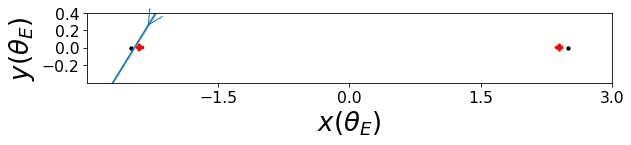

In [9]:
plot_file = './wide_binary_model_fullplane.png'
plot_geometry(usbl1, usbl1_parameters, plot_file, xmin=-3.0, xmax=3.0, ymin=-0.4, ymax=0.4, critical_curves=False, plot_legend=False)

(<Figure size 750x750 with 1 Axes>, None)

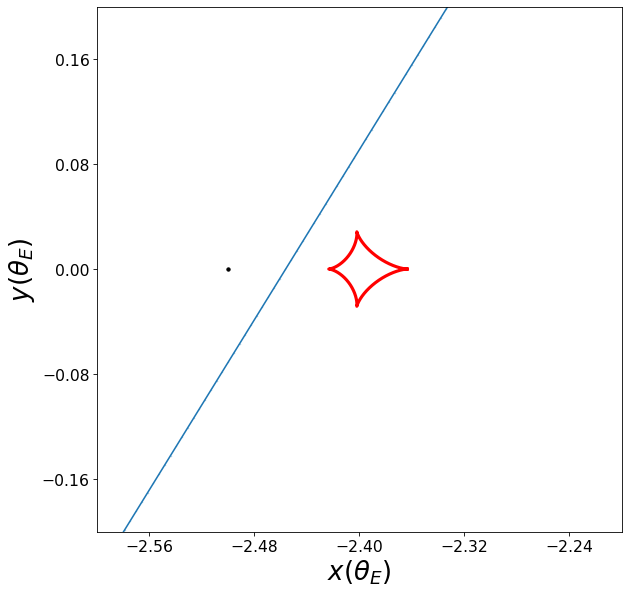

In [10]:
plot_file = './wide_binary_model.png'
plot_geometry(usbl1, usbl1_parameters, plot_file, xmin=-2.6, xmax=-2.2, ymin=-0.2, ymax=0.2, critical_curves=False, plot_legend=False)

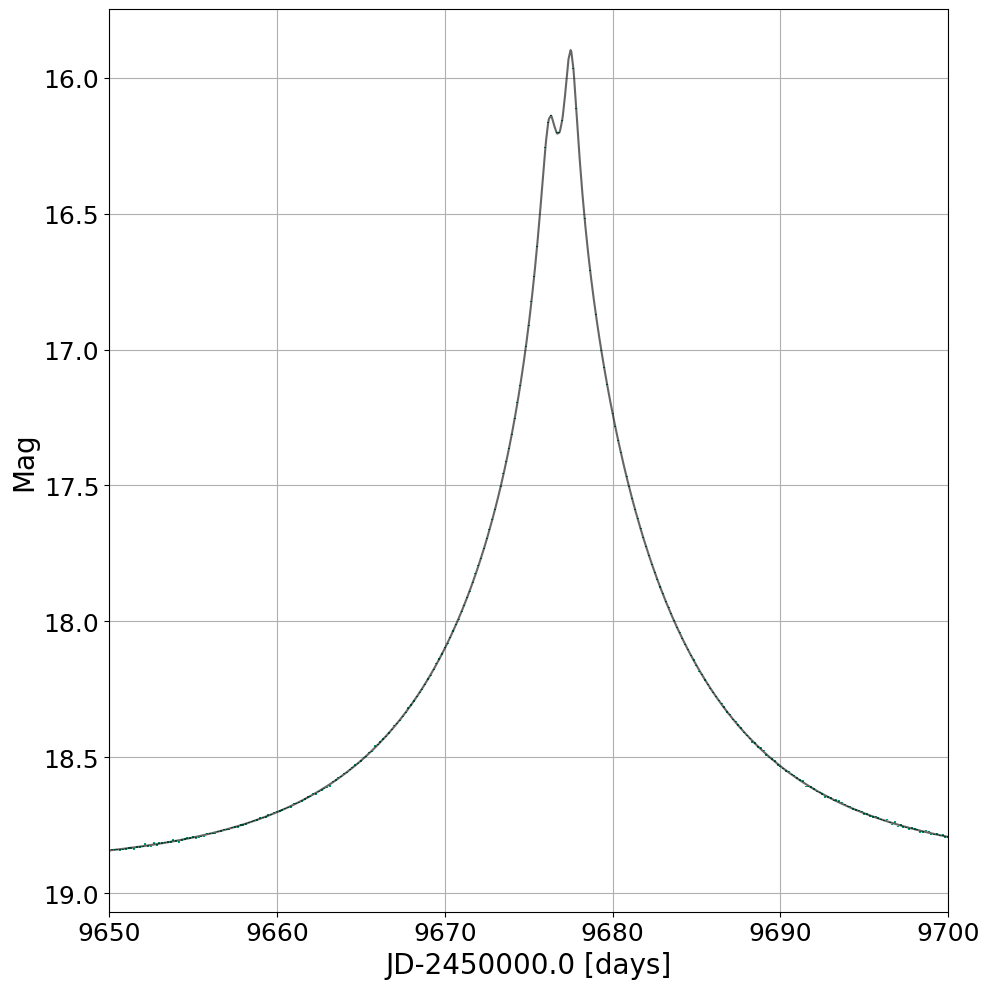

In [21]:
pyLIMA_parameters_wide = usbl1.compute_pyLIMA_parameters(usbl1_parameters)
plot_file = './wide_binary_lc.png'
plot_lc(usbl1, pyLIMA_parameters_wide, plot_file, xmin=9650, xmax=9700)

## Close binary model

In [12]:
sim_event2 = event.Event(ra=265.0, dec=-17.5)
sim_event2.name = 'Sim_event_2'

In [13]:
tel2 = simulator.simulate_a_telescope(name='tel1', time_start=2459500.0,
                                        time_end=2459750.0, sampling=4,
                                        location='Earth', camera_filter='I',
                                        uniform_sampling=True, astrometry=False)
sim_event2.telescopes.append(tel2)
sim_event2.check_event()

check_event  : Everything looks fine...


In [22]:
usbl2 = USBL_model.USBLmodel(sim_event2, parallax=['None', 0.0], blend_flux_parameter='ftotal')
usbl2_parameters = [2459651.8548187, -0.12, 20.0, 0.00001, 0.4, 1.0, 45.0, 2500.243993694058444, 2500.243993694058444]
pyLIMA_parameters_close = usbl2.compute_pyLIMA_parameters(usbl2_parameters)

In [23]:
simulator.simulate_lightcurve(usbl2, pyLIMA_parameters_close)

(<Figure size 750x750 with 1 Axes>, None)

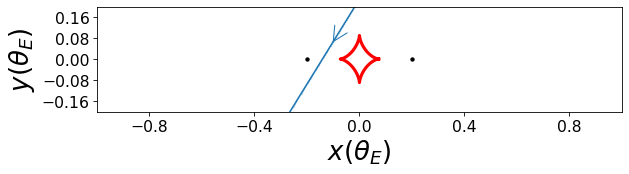

In [24]:
plot_file = './close_binary_model_fullplane.png'
plot_geometry(usbl2, usbl2_parameters, plot_file, xmin=-1.0, xmax=1.0, ymin=-0.2, ymax=0.2, critical_curves=False, plot_legend=False)

(<Figure size 750x750 with 1 Axes>, None)

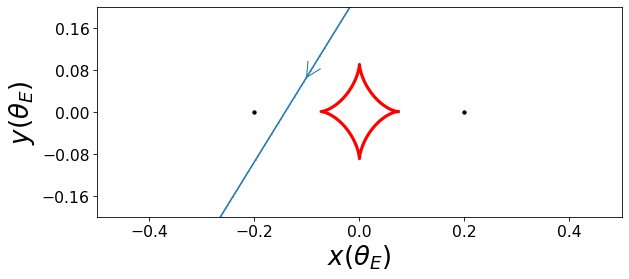

In [25]:
plot_file = './close_binary_model.png'
plot_geometry(usbl2, usbl2_parameters, plot_file, xmin=-0.5, xmax=0.5, ymin=-0.2, ymax=0.2, critical_curves=False, plot_legend=False)

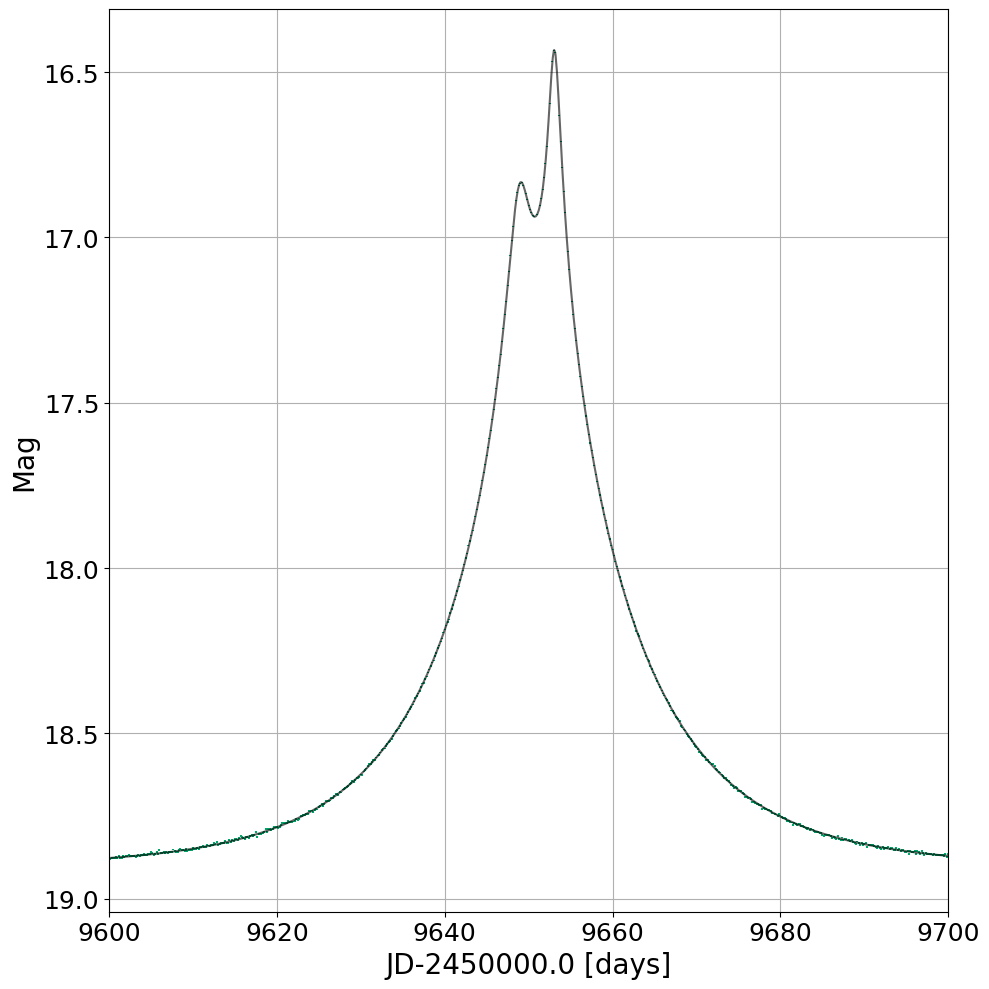

In [26]:
pyLIMA_parameters_wide = usbl2.compute_pyLIMA_parameters(usbl2_parameters)
plot_file = './close_binary_lc.png'
plot_lc(usbl2, pyLIMA_parameters_wide, plot_file, xmin=9600, xmax=9700)

## Caustic morphologies

In [ ]:
sim_event3a = event.Event(ra=265.0, dec=-17.5)
sim_event3a.name = 'Sim_event_1'

sim_event3b = event.Event(ra=265.0, dec=-17.5)
sim_event3b.name = 'Sim_event_2'

sim_event3c = event.Event(ra=265.0, dec=-17.5)
sim_event3c.name = 'Sim_event_2'

In [ ]:
sim_event3a.telescopes.append(tel1)
sim_event3a.check_event()

sim_event3b.telescopes.append(tel1)
sim_event3b.check_event()

sim_event3c.telescopes.append(tel1)
sim_event3c.check_event()

In [ ]:
# Define parameters 
# t0, u0, tE, rho, s, q, alpha, fsource, ftotal
# Wide binary model
usbl3a = USBL_model.USBLmodel(sim_event3a, parallax=['None', 0.0], blend_flux_parameter='ftotal')
usbl3a_parameters = [2459651.8548187, 0.005, 20.0, 0.00001, 3.0, 1.0, 0.0, 2500.243993694058444, 2500.243993694058444]
pyLIMA_parameters_3a = usbl1.compute_pyLIMA_parameters(usbl3a_parameters)

# Intermediate binary model
usbl3b = USBL_model.USBLmodel(sim_event3b, parallax=['None', 0.0], blend_flux_parameter='ftotal')
usbl3b_parameters = [2459651.8548187, 0.005, 20.0, 0.00001, 1.0, 1.0, 0.0, 2500.243993694058444, 2500.243993694058444]
pyLIMA_parameters_3b = usbl2.compute_pyLIMA_parameters(usbl3b_parameters)

# Close binary model
usbl3c = USBL_model.USBLmodel(sim_event2, parallax=['None', 0.0], blend_flux_parameter='ftotal')
usbl3c_parameters = [2459651.8548187, 0.005, 20.0, 0.00001, 0.4, 1.0, 0.0, 2500.243993694058444, 2500.243993694058444]
pyLIMA_parameters_3c = usbl3c.compute_pyLIMA_parameters(usbl3c_parameters)

In [ ]:
plot_file = './wide_binary_caustic.png'
plot_geometry(usbl3a, usbl3a_parameters, plot_file, xmin=-2.0, xmax=2.0, ymin=-0.5, ymax=0.5, critical_curves=False, plot_legend=False)

In [ ]:
plot_file = './intermediate_binary_caustic.png'
plot_geometry(usbl3b, usbl3b_parameters, plot_file, xmin=-2.0, xmax=2.0, ymin=-1.0, ymax=1.0, critical_curves=False, plot_legend=False)

In [ ]:
plot_file = './close_binary_caustic.png'
plot_geometry(usbl3c, usbl3c_parameters, plot_file, xmin=-0.2, xmax=0.2, ymin=-0.2, ymax=0.2, critical_curves=False, plot_legend=False)